In [1]:
import pandas as pd
import os
import numpy as np
import re

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    # Get clades in preorder and keep only terminals
    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
phylDF

,Phy_order,sample,sample_sex,assembly_type,hg_short,haplogroup_ISOGG_v15.73,haplogroup_yHaplo_term_marker,Y_known_SVs_Teitz-2018,study_generation
GoodSampleNames,,,,,,,,,
HG02984,1,HG02984,male,vrk-hic,A0,A0a1,V153,NaN,2025
HG01890,2,HG01890,male,HGSVC3,A0,A0b,L1038,ref,2024
HG02647,3,HG02647,male,vrk-thc,A1,A1a,M31,NaN,2025
HG02668,4,HG02668,male,vrk-thc,A1,A1a,M31,NaN,2025
HG02666,5,HG02666,male,HGSVC3,A1,A1a,M31,ref,2024
...,...,...,...,...,...,...,...,...,...
HG03017,132,HG03017,male,vrk-hic,R2,R2,L266,NaN,2025
HG04160,133,HG04160,male,vrk-hic,R2,R2,L266,NaN,2025
HG03732,134,HG03732,male,HGSVC3,R2,R2,L266,NaN,2024


In [5]:
import os
import re
import pandas as pd

directory = '/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/CombinedFiles/'

geneNames = ['VCY','CDY','BPY2','HSFY','PRY','XKRY','DAZ','TSPY','RBMY']

prefix_pattern = r'^(' + '|'.join(map(re.escape, geneNames)) + r')'

all_hits = []

for file in os.listdir(directory):
    if file.endswith('.csv'):
        sample = file.split("_")[0]
        df = pd.read_csv(os.path.join(directory, file))

        df2 = df[(df['PangenomeGraph'] == 'CALLED') & (df['Liftoff'] == 'CALLED') & (df['RM_Amplicon_Caller'] == 'NOT_CALLED') & (df['contig'] == sample+"_chrY")].copy()
        df2['matched_prefix'] = df2['gene_name'].fillna('').str.extract(prefix_pattern, expand=False)

        ampliconic_df = df2[df2['matched_prefix'].notna()].copy()
        ampliconic_df2 = ampliconic_df[
            ampliconic_df['biotype'].fillna('').str.contains('pseudogene', case=False)
        ].copy()

        ampliconic_df2['sample_from_file'] = sample

        all_hits.append(ampliconic_df2)

final_ampliconic_df = pd.concat(all_hits, ignore_index=True)

In [6]:
heatmap_df = (
    final_ampliconic_df
    .groupby(['sample_from_file', 'matched_prefix'])
    .size()
    .unstack(fill_value=0)
)

heatmap_df = heatmap_df.reindex(columns=geneNames, fill_value=0)
sample_order = [s for s in phylogeneticOrder if s in heatmap_df.index]
heatmap_df = heatmap_df.loc[sample_order]

In [20]:
#final_ampliconic_df[['sample','contig','start_merged','end_merged','matched_prefix','gene_name','biotype','seqclass','Liftoff','PangenomeGraph','Liftoff_Coordinates','PangenomeGraph_Coordinates']].to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/AmpliconicGenePseudogenes.csv")                                                                                                                                                                                                        

In [17]:
for prefix in set(final_ampliconic_df['matched_prefix']):
    final_ampliconic_df2 = final_ampliconic_df[final_ampliconic_df['matched_prefix']==prefix].copy()
    print(prefix, collections.Counter(final_ampliconic_df2['seqclass']))

CDY Counter({'AMPL7': 1452, 'AMPL6': 389, 'AMPL2': 140, 'XDR3': 140, 'P5-dist': 138, 'P5-prox': 106, 'P1-dist': 46, 'P1-prox': 35, 'yellow': 11, 'P3-dist': 10, 'IR5-3': 5, 'P3-prox': 2})
XKRY Counter({'AMPL6': 366, 'AMPL7': 226, 'P5-dist': 70, 'P5-prox': 53, 'P4-prox': 18, 'P4-dist': 11, 'P1-dist': 11, 'P1-prox': 8, 'yellow': 7})
RBMY Counter({'AMPL7': 1638, 'AMPL2': 1400, 'XDR8': 140, 'AMPL1_IR3d': 120, 'P1-dist': 27, 'IR3-prox': 20, 'P1-prox': 17, 'P3-dist': 12, 'P3-spacer': 9, 'green': 5, 'P3-prox': 2, 'teal2': 2, 'blue': 1})
BPY2 Counter({'AMPL2': 140, 'UNASSIGNED': 1})
HSFY Counter({'AMPL7': 494, 'XDR1': 140, 'XDR8': 140, 'P1-dist': 13, 'P1-prox': 11, 'P3-dist': 10, 'P3-prox': 2})
TSPY Counter({'AMPL7': 1321, 'AMPL2': 1259, 'AMPL1_IR3d': 360, 'IR2-dist': 63, 'IR3-prox': 60, 'UNASSIGNED': 9, 'P3-spacer': 4, 'P3-dist': 2, 'teal2': 2})
PRY Counter({'AMPL7': 3})


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_9867/1631035664.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


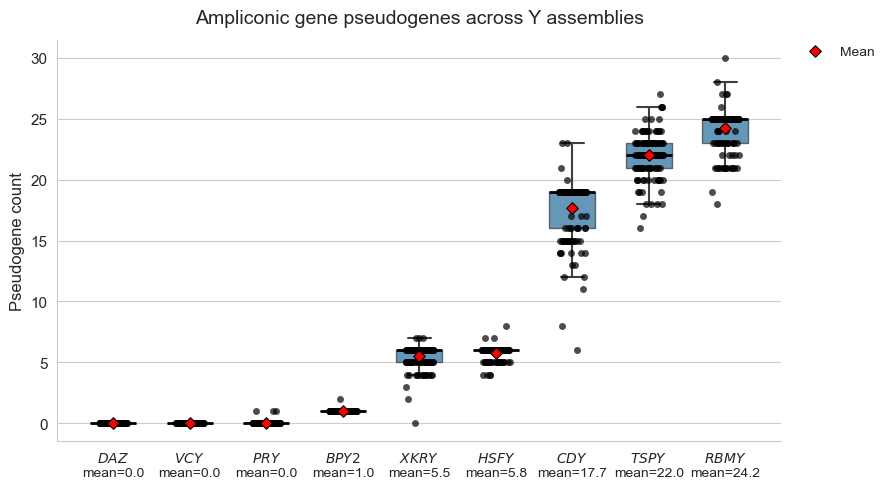

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = heatmap_df.reset_index()
gene_order = ["DAZ", "VCY", "PRY", "BPY2", "XKRY", "HSFY", "CDY", "TSPY", "RBMY"]

long_df = plot_df.melt(
    id_vars="sample_from_file",
    value_vars=gene_order,
    var_name="Gene",
    value_name="Count"
)

mean_df = (
    long_df.groupby("Gene", as_index=False)["Count"]
    .mean()
    .rename(columns={"Count": "MeanCount"})
)

mean_map = mean_df.set_index("Gene")["MeanCount"].to_dict()

sns.set_style("whitegrid")
plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    data=long_df,
    x="Gene",
    y="Count",
    order=gene_order,
    width=0.6,
    showfliers=False,
    boxprops=dict(alpha=0.75),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2, color="black")
)

sns.stripplot(
    data=long_df,
    x="Gene",
    y="Count",
    order=gene_order,
    color="black",
    size=5,
    alpha=0.7,
    jitter=0.18,
    ax=ax
)

x_positions = range(len(gene_order))
ax.scatter(
    x_positions,
    mean_df.set_index("Gene").loc[gene_order, "MeanCount"],
    marker="D",
    s=35,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    zorder=5,
    label="Mean"
)

ax.set_xlabel("")
ax.set_ylabel("Pseudogene count", fontsize=12)
ax.set_title("Ampliconic gene pseudogenes across Y assemblies", fontsize=14, pad=12)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=11)

xtick_labels = [
    rf"$\it{{{g}}}$" + "\n" + f"mean={mean_map[g]:.1f}"
    for g in gene_order
]
ax.set_xticklabels(xtick_labels)

ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
sns.despine()
plt.tight_layout()
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/ampliconicGenes/ampliconic_gene_pseudogenes_boxplot.03172026.pdf", bbox_inches="tight")
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/ampliconicGenes/ampliconic_gene_pseudogenes_boxplot.03172026.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
import collections
#final_ampliconic_df[final_ampliconic_df['sample']=='NA18971']

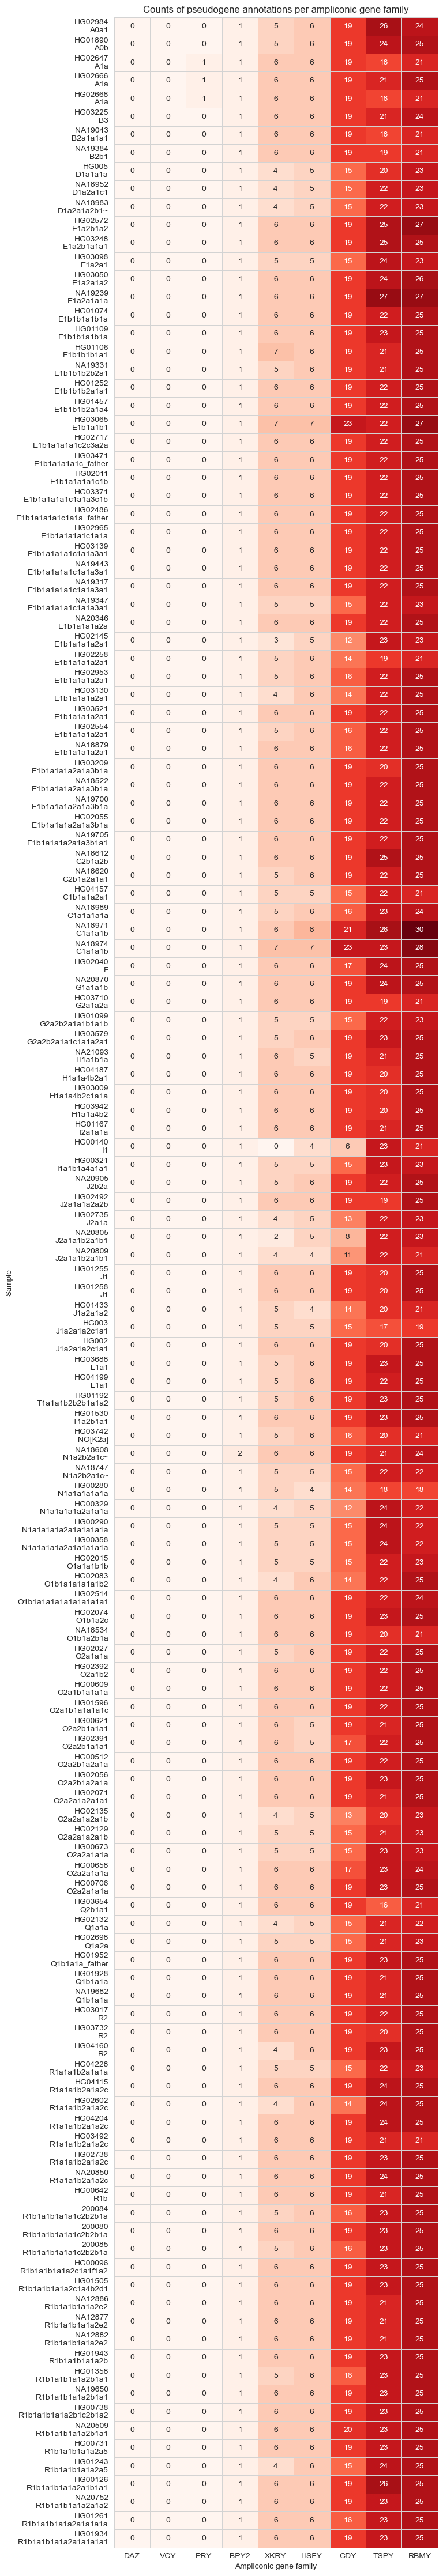

In [9]:
heatmap_df = (
    final_ampliconic_df
    .groupby(['sample_from_file', 'matched_prefix'])
    .size()
    .unstack(fill_value=0)
)

heatmap_df = heatmap_df.reindex(columns=gene_order, fill_value=0)
sample_order = [s for s in phylogeneticOrder if s in heatmap_df.index]
heatmap_df = heatmap_df.loc[sample_order]

y_labels = []
for sample in heatmap_df.index:
    hap = haplogroups.get(sample, '')
    if hap != '':
        y_labels.append(f"{sample}\n{hap}")
    else:
        y_labels.append(sample)

plt.figure(figsize=(8, max(6, len(heatmap_df) * 0.32)))

ax = sns.heatmap(
    heatmap_df,
    cmap='Reds',
    linewidths=0.5,
    linecolor='lightgrey',
    yticklabels=y_labels,
    annot=True,
    fmt='d',
    cbar=None
)

plt.xlabel('Ampliconic gene family')
plt.ylabel('Sample')
plt.title('Counts of pseudogene annotations per ampliconic gene family')
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.subplots_adjust(left=0.28)
plt.savefig('/Ampliconic_Gene_Pseudogenes.03162026.pdf')
plt.show()